
# Practical 11: **ResNet (Residual Learning)**- Going Deeper with Skip Connections


##  Learning Goals
By the end of this practical you will be able to:
- Explain the idea of **residual learning** and why **skip connections** enable very deep networks.
- Inspect **ResNet‑18/34/50** architecture and parameter counts, comparing with **AlexNet**, **VGG‑16**, **GoogLeNet**, and **SqueezeNet**.
- Fine‑tune a **pretrained ResNet** on the **same flowers dataset** from Practicals 7–10.
- Evaluate with the **same metrics** used before (accuracy, confusion matrix, per‑class precision/recall/F1) and visualize predictions.



## Dataset
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)
- We will reuse the **same flowers dataset** and **the same data split** (`train/`, `val/`, `test/`) as in Practicals **7–10**.  
- Please keep the folder structure identical to avoid breaking the loaders.

> **Tip:** If you run in Google Colab, mount your Drive first and set `DATA_DIR` to the same path you used earlier.


In [ ]:

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

# ===== Keep names identical to earlier practicals wherever possible =====
# Adjust DATA_DIR if your path differs; folder structure must be .../train, .../val, .../test
import os, copy, time, math, itertools, json, random
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===== Paths and Hyperparameters (keep consistent) =====
# Set this to the SAME folder you used in Practicals 7–10
DATA_DIR = "/content/drive/MyDrive/flowers"  # <-- change if needed
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-3

# Image transforms (keep consistent with previous practicals)
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets & Loaders (same variable names as before)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


Using device: cuda
Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']



## Why **ResNet**? The power of **Residual Learning**
Deep CNNs used to suffer from **degradation**: adding more layers often **increased** training error because gradients vanished and optimization became unstable.

**ResNet (2015)** fixes this by adding **skip connections** so each block learns a *residual* (a small correction) instead of a full mapping:

`y = F(x; W) + x`

Rather than learning `x → y` directly, the block learns the **difference** `F(x)`, while the **identity shortcut** passes `x` forward unchanged. This:

* Improves gradient flow during backprop → **easier optimization**
* Enables **much deeper** networks (18/34/50/101/152 layers) with strong accuracy
* Encourages **feature reuse** and **stable training**



### Residual Block:

<center>
<img src="https://raw.githubusercontent.com/zaidalhuda/Hands-On-Computer-Vision-Series-A-Practical-Learning-Journey/main/notebooks/images/Residual-Block.png" alt="Residual Block" width="500"/>
</center>

### Identity vs. Projection Shortcuts
- **Identity shortcut**: when input and output **shapes match**, we just add: `out = F(x) + x`.
- **Projection shortcut**: when shapes **don’t match** (e.g., stride 2 or channel change), we add a **1×1 conv** to the skip path to align sizes:  
  `out = F(x) + W_s * x` (where `W_s` is the 1×1 conv).

### A small bit of math

A residual block outputs
`y = F(x; W) + x`

If the desired mapping is `H(x)`, the block learns the **residual**
`R(x) = H(x) - x`, so `y = x + R(x)`.

**Why gradients flow better.** During backpropagation, the gradient w\.r.t. the input includes an identity term from the skip path:
`dL/dx = dL/dy * (∂F/∂x + I)`
The `+ I` provides a **direct path** for gradients. Even if `∂F/∂x` is small, the signal does not vanish.

> If the block changes shape (downsampling or channel change), the skip uses a 1×1 projection:
> `y = F(x; W) + W_s * x`



# How It Recognizes Flowers

## The Memory Botanist

**Think of ResNet as a botanical scholar who never forgets previous flower insights while learning new ones.**

### Step-by-Step Process:

**1. Initial Convolution:**
- Sets up basic feature detection
- **Flower detection**: "Basic botanical patterns established"

**2. Residual Blocks: Learning + Memory**

Each Residual Block has a unique botanical approach:

**The Learning Path:**
- **Conv → BatchNorm → ReLU → Conv**: Learns new flower features
- **Flower detection**: "Let me learn some improvements to current flower understanding"

**The Memory Path (Skip Connection):**
- **Direct connection**: Preserves all previous botanical learning
- **Flower detection**: "I will remember everything I knew about flowers before"

**The Combination:**
- **New Learning + Previous Memory**: Best of both botanical worlds
- **Flower detection**: "Original flower features + new improvements = better flower understanding"

**3. Progressive Residual Blocks:**
- **Early blocks**: "Basic features + small improvements = better petal edges and color patterns"
- **Middle blocks**: "Previous understanding + shape refinements = clearer flower parts"
  - Distinguishing Lilly vs Tulip: "Both are elongated, but Lilly has trumpet shape + Tulip has cup shape"
- **Deep blocks**: "All accumulated knowledge + final insights = confident flower identification"
  - Lotus recognition: "Water background + circular petals + pink/white color + all previous evidence = definitely Lotus"

**4. Deep Understanding (50-152 layers):**
- Each block builds on ALL previous botanical learning
- **Output**: "95% confident this is a Lotus - backed by 50 layers of accumulated botanical evidence!"

### ResNet's Character:
- **Never forgets**: Always preserves previous botanical learning
- **Goes very deep**: Can learn from 100+ layers of flower analysis safely
- **Robust**: Excellent performance across many flower classification tasks

### How ResNet Improves on Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet | SqueezeNet | ResNet |
|--------|---------|---------|-----------|------------|---------|
| **Max Depth** | 8 layers | 19 layers | 22 layers | 22 layers | 152+ layers |
| **Key Innovation** | CNN + GPU | Systematic depth | Inception | Fire modules | Skip connections |
| **Gradient Problem** | Limited depth | Vanishing gradients | Solved by design | Solved by efficiency | Solved by skip connections |
| **Flower Recognition** | Basic deep | Methodical deep | Multi-scale smart | Ultra-efficient | Very deep memory |
| **Training Stability** | Challenging | Difficult | Good | Good | Excellent |
| **Accuracy** | 85% | 92% | 93% | 85% | 95% |

**Key Improvement**: ResNet's skip connections enable much deeper networks (50-152 layers) that achieve superior flower recognition accuracy by building cumulative botanical knowledge - crucial for distinguishing subtle differences between flower types like different Orchid varieties.


### ResNet
- **Problem before ResNet:** Making CNNs deeper (more layers) often made **training worse** (higher error), even with enough data → called **degradation** (not just overfitting).
- **Key idea:** Add a **shortcut** that copies the input forward so layers only learn a **residual (small correction)**. If the best thing is to “do nothing”, the block can simply pass the input unchanged.
- **What changes?** Optimization becomes easier → we can train **very deep** networks (50, 101, 152 layers) that generalize well.
- **Two block types:**  
  - **BasicBlock** (ResNet‑18/34): `3×3 → 3×3` (+ identity)  
  - **Bottleneck** (ResNet‑50/101/152): `1×1 (reduce) → 3×3 → 1×1 (expand)` (+ identity)
- **Where is downsampling?** At the start of some stages using **stride=2** (either in the main path or the skip path) to halve H×W and increase channels.
- **Why it works:** Gradients can always flow through the **identity path**, so signals don’t vanish as quickly.



### Anatomy of a ResNet (stages & shapes)
A ResNet has an initial **stem** then 4 **stages** (`layer1`→`layer4`). Typical shapes (for **224×224** input):

| Part | Operation | Output size (H×W×C) — ResNet‑18/34 |
|---|---|---|
| **Stem** | 7×7 conv, stride 2 → 3×3 maxpool, stride 2 | 56×56×64 |
| **layer1** | BasicBlocks (no downsample) | 56×56×64 |
| **layer2** | First block downsample (stride 2) | 28×28×128 |
| **layer3** | First block downsample (stride 2) | 14×14×256 |
| **layer4** | First block downsample (stride 2) | 7×7×512 |
| **Head** | Global Average Pool → FC | 1×1×512 → num_classes |

For **ResNet‑50**, channels per stage are the same {64,128,256,512} but each block is **bottleneck** (internal 1×1→3×3→1×1).


In [ ]:
# Feature map sizes through ResNet (helpful for intuition)
import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

try:
    weights = ResNet18_Weights.IMAGENET1K_V1
except Exception:
    weights = None

_demo_model = resnet18(weights=weights)
_demo_model.fc = nn.Identity()  # drop final FC for shape tracing
_demo_model.eval()

shapes = []
def hook(module, input, output):
    name = module.__class__.__name__
    if isinstance(output, torch.Tensor):
        shapes.append((name, list(output.shape)))
    return None

hooks = []
for name, m in _demo_model.named_children():
    if name in ["conv1","maxpool","layer1","layer2","layer3","layer4"]:
        hooks.append(m.register_forward_hook(hook))

x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    _ = _demo_model(x)

for h in hooks: h.remove()

print("Feature map shapes for a 224x224 input:")
for name, shape in shapes:
    print(f"{name:<8s} -> {shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


Feature map shapes for a 224x224 input:
Conv2d   -> [1, 64, 112, 112]
MaxPool2d -> [1, 64, 56, 56]
Sequential -> [1, 64, 56, 56]
Sequential -> [1, 128, 28, 28]
Sequential -> [1, 256, 14, 14]
Sequential -> [1, 512, 7, 7]


In [ ]:
# Parameter counts per stage (which parts are heavy?)
import torch.nn as nn
from collections import defaultdict

def params_by_stage(model: nn.Module):
    buckets = defaultdict(int)
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        top = n.split('.')[0]
        buckets[top] += p.numel()
    return dict(buckets)

stage_params = params_by_stage(_demo_model)
for k in ["conv1","layer1","layer2","layer3","layer4","fc"]:
    if k in stage_params:
        print(f"{k:<7s}: {stage_params[k]:,} params")

conv1  : 9,408 params
layer1 : 147,968 params
layer2 : 525,568 params
layer3 : 2,099,712 params
layer4 : 8,393,728 params



### Fine‑tuning tips
1. **Start with pretrained** weights (`weights=...`) — converges faster on small datasets.  
2. **Replace `fc`** with `nn.Linear(in_features, num_classes)`.  
3. **Option A:** Train **all layers** with a small LR (e.g., `1e‑3`).  
4. **Option B:** **Freeze early stages** (`conv1`, `layer1`, sometimes `layer2`) and train the rest with a slightly higher LR; then **unfreeze** and fine‑tune all with a lower LR.  
5. Keep augmentations and normalization the **same** as previous practicals for fair comparison.


In [ ]:
# Freeze/unfreeze helpers
def freeze_stages(model, freeze_until=("layer2",)):
    """Freeze conv1, bn1, layer1, and optionally layer2 to stabilize early training."""
    to_freeze = ["conv1","bn1","layer1"]
    if "layer2" in freeze_until:
        to_freeze.append("layer2")
    for name, p in model.named_parameters():
        if name.split(".")[0] in to_freeze:
            p.requires_grad = False

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

# Example usage:
# freeze_stages(resnet, freeze_until=("layer2",))
# ... train a bit ...
# unfreeze_all(resnet)


### Note: ResNet‑v1 vs ResNet‑v2 (pre‑activation)
- **This notebook** uses the **original (v1)** ordering: `Conv → BN → ReLU`, then add the skip.  
- **ResNet‑v2** moves **BN+ReLU before the convs** (pre‑activation), which further eases optimization for very deep nets.  
Both follow the same residual idea; for our flowers dataset either works well.



### Basic vs. Bottleneck Blocks
- **Basic Block** *(ResNet‑18/34)*: two 3×3 convs + skip connection.  
- **Bottleneck Block** *(ResNet‑50/101/152)*: 1×1 **reduce** → 3×3 **process** → 1×1 **expand** (+ skip).  
If spatial dimensions or channels change, the skip path uses a **1×1 convolution** to match shapes.

> In TorchVision: `resnet18/resnet34` use **BasicBlock**; `resnet50/101/152` use **Bottleneck**.



## Inspecting **ResNet** Structure and Parameters
We’ll instantiate a ResNet and **replace the final layer** to match our `num_classes`. Then we’ll print a **layer summary** and **parameter counts** (total and trainable).


In [ ]:

from torchvision.models import resnet18, ResNet18_Weights

# Use pretrained weights (recommended for small datasets). If offline, set weights=None.
try:
    weights = ResNet18_Weights.IMAGENET1K_V1
except Exception:
    weights = None

resnet = resnet18(weights=weights)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

resnet = resnet.to(device)

def count_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(resnet)
print(f"ResNet-18 — total params: {total:,} | trainable: {trainable:,}")
print(resnet)


ResNet-18 — total params: 11,179,077 | trainable: 11,179,077
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 


### Design Comparison (Parameters & Notes)
We’ll compute parameter counts for the same family of models used in Practicals 7–10 and compare them with ResNet.


In [ ]:

from torchvision.models import alexnet, vgg16, googlenet, squeezenet1_0, resnet50

def param_count(model):
    return sum(p.numel() for p in model.parameters())

models_for_compare = {
    "AlexNet (2012)": alexnet(num_classes=1000),
    "VGG-16 (2014)": vgg16(num_classes=1000),
    "GoogLeNet (2014)": googlenet(num_classes=1000, aux_logits=False),
    "SqueezeNet1.0 (2016)": squeezenet1_0(num_classes=1000),
    "ResNet-18 (2015)": resnet18(num_classes=1000),
    "ResNet-50 (2015)": resnet50(num_classes=1000),
}

print("{:<22s} {:>12s}".format("Model", "Params"))
print("-"*36)
for name, m in models_for_compare.items():
    print("{:<22s} {:>12,d}".format(name, param_count(m)))


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Model                        Params
------------------------------------
AlexNet (2012)           61,100,840
VGG-16 (2014)           138,357,544
GoogLeNet (2014)          6,624,904
SqueezeNet1.0 (2016)      1,248,424
ResNet-18 (2015)         11,689,512
ResNet-50 (2015)         25,557,032



## Training & Evaluation
We keep the **same training loop** and **evaluation style** as Practicals 7–10:
- Optimizer: `Adam` (learning rate `1e-3`, feel free to adjust).
- Loss: `CrossEntropyLoss`.
- Scheduler: optional `ReduceLROnPlateau` on validation accuracy.
- Metrics: accuracy, confusion matrix, classification report.


In [ ]:

def accuracy(output, target):
    with torch.no_grad():
        preds = output.argmax(dim=1)
        return (preds == target).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, correct, running_loss = 0, 0, 0.0
    all_preds, all_targets = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(labels.cpu().numpy())

    avg_loss = running_loss / max(1, total)
    acc = correct / max(1, total)
    return avg_loss, acc, np.concatenate(all_preds), np.concatenate(all_targets)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, total, correct = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / max(1, total), correct / max(1, total)

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss);   history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:02d}: train_loss={tr_loss:.4f} acc={tr_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

    model.load_state_dict(best_wts)
    return model, history

# Train
model = resnet  # from above
model, history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)


Epoch 01: train_loss=0.7126 acc=0.745 | val_loss=0.7425 acc=0.774
Epoch 02: train_loss=0.5267 acc=0.817 | val_loss=0.6063 acc=0.792
Epoch 03: train_loss=0.4439 acc=0.847 | val_loss=0.3664 acc=0.868
Epoch 04: train_loss=0.3907 acc=0.862 | val_loss=0.4725 acc=0.828
Epoch 05: train_loss=0.3351 acc=0.879 | val_loss=0.3484 acc=0.888
Epoch 06: train_loss=0.3106 acc=0.892 | val_loss=0.3475 acc=0.878
Epoch 07: train_loss=0.2606 acc=0.905 | val_loss=0.3656 acc=0.876
Epoch 08: train_loss=0.2882 acc=0.901 | val_loss=0.3214 acc=0.894
Epoch 09: train_loss=0.2176 acc=0.924 | val_loss=0.3797 acc=0.880
Epoch 10: train_loss=0.2284 acc=0.919 | val_loss=0.3335 acc=0.882
Epoch 11: train_loss=0.1922 acc=0.933 | val_loss=0.3664 acc=0.896
Epoch 12: train_loss=0.2065 acc=0.924 | val_loss=0.3338 acc=0.896
Epoch 13: train_loss=0.1794 acc=0.940 | val_loss=0.3682 acc=0.912
Epoch 14: train_loss=0.1656 acc=0.944 | val_loss=0.2790 acc=0.916
Epoch 15: train_loss=0.1491 acc=0.952 | val_loss=0.3518 acc=0.888
Epoch 16: 

Test — loss: 0.1535, acc: 0.970
Model saved to: ResNet18_flowers.pth

Classification Report (Test):

              precision    recall  f1-score   support

       Lilly      0.959     0.940     0.949       100
       Lotus      0.980     0.960     0.970       100
      Orchid      0.951     0.980     0.966       100
   Sunflower      1.000     1.000     1.000       100
       Tulip      0.960     0.970     0.965       100

    accuracy                          0.970       500
   macro avg      0.970     0.970     0.970       500
weighted avg      0.970     0.970     0.970       500



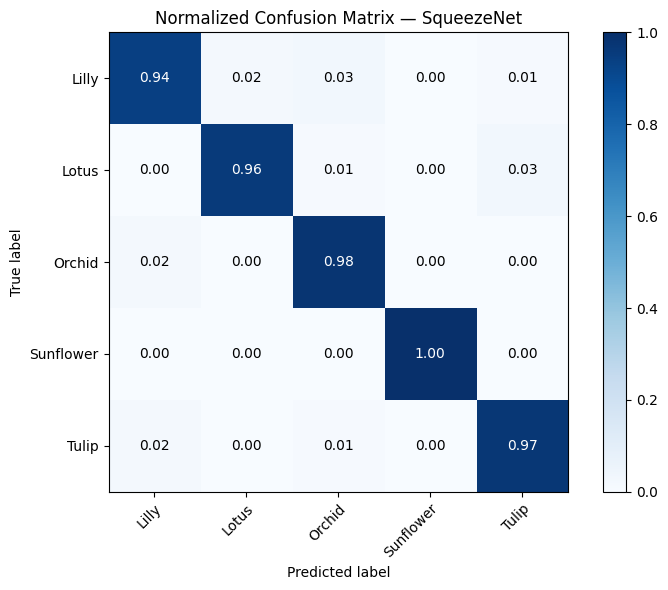

In [ ]:

# Final Test Evaluation (same style as earlier practicals)
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, test_preds, test_targets = evaluate(model, test_loader, criterion)
print(f"Test — loss: {test_loss:.4f}, acc: {test_acc:.3f}")

# Save best model (same pattern as earlier)
model_path = 'ResNet18_flowers.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Confusion Matrix & Classification Report
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

y_pred, y_true = collect_preds(model, test_loader, device)
print("\nClassification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label',
       title='Normalized Confusion Matrix — SqueezeNet')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
# write values
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()



## Visualize Predictions
We display a small grid of **test images** with **Pred / True** labels (same style as before).


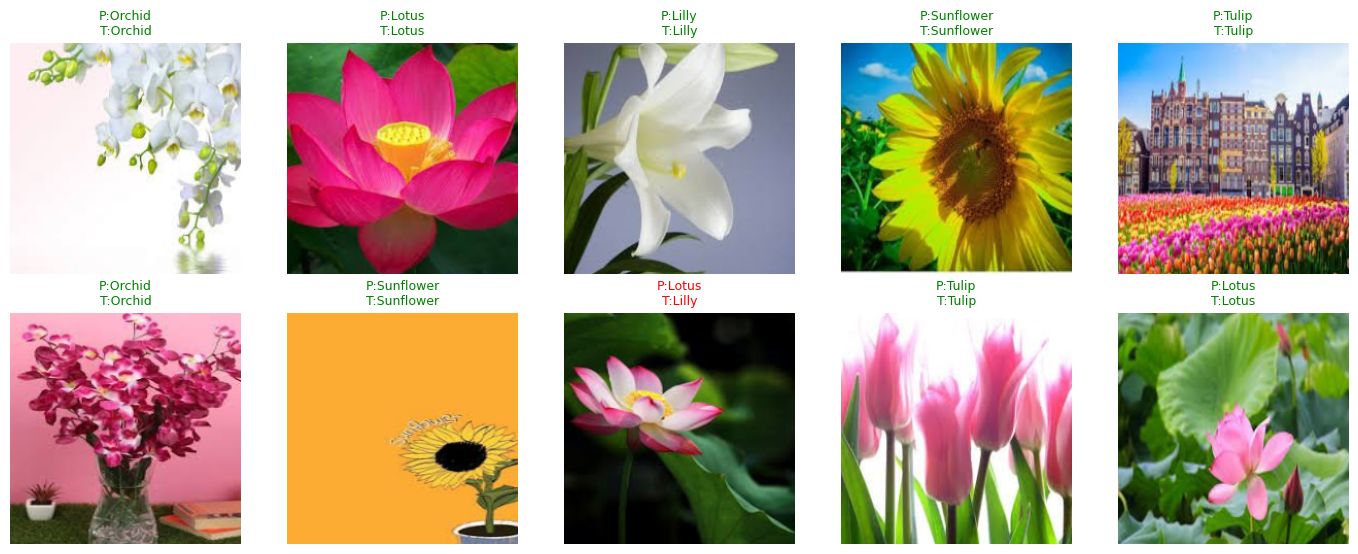

In [ ]:

import matplotlib.pyplot as plt
# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(model, test_ds, class_names, k_per_class=2, max_total=20)



## Key Takeaways
- **Residual learning** and **skip connections** allow training **much deeper** CNNs while keeping optimization stable.
- **ResNet‑18** offers a strong **accuracy‑to‑parameters** trade‑off; **ResNet‑50** often improves accuracy further with **bottleneck** blocks.
- Compared with **AlexNet** and **VGG‑16**, ResNet is **deeper** but **easier to train**; compared with **GoogLeNet**, it trades multi‑branch modules for **identity shortcuts**; relative to **SqueezeNet**, ResNet typically has **more parameters** but stronger accuracy.
- Fine‑tuning **pretrained ImageNet weights** + standard augmentations is very effective on small datasets like our **flowers** split.



## Next Practical (Practical 12): **MobileNet** - Efficient CNNs with **Depthwise‑Separable** Convolutions
In the next practical, we’ll study **MobileNet**, connect its design choices to our comparisons here, and fine‑tune it on the same flowers dataset.



---

> This practical was designed to give you hands‑on experience with **ResNet**, a clear comparison to **AlexNet**, **VGG‑16**, **GoogLeNet**, and **SqueezeNet**, and practical skills in fine‑tuning pretrained models for image classification.
